In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_hist_gradient_boosting  
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import median_absolute_error
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from matplotlib.patches import ConnectionPatch
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import accuracy_score
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import auc
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedKFold
from scipy.stats import mode
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold
import numpy as np

id: 학생을 구분하는 고유 번호임. 데이터셋에서 각각의 학생을 식별하는 데 사용됨.

Marital status (결혼 상태): 학생의 결혼 상태를 나타냄. 예를 들어, 미혼(Single), 기혼(Married), 이혼(Divorced) 같은 값이 있음.

Application mode (신청 모드): 학생이 입학 신청을 어떤 방식으로 했는지 나타냄. 예를 들어, 온라인 신청, 오프라인 신청, 추천 이런 것임.

Application order (신청 순서): 학생이 지원한 학교나 프로그램의 우선순위를 나타냄. 예를 들어, 첫 번째 선택(1), 두 번째 선택(2) 등이 있음.

Course (코스): 학생이 신청한 학업 과정이나 전공임. 예를 들어, 컴퓨터 과학, 경영학, 문학 등이 있음.

Daytime/evening attendance (주간/야간 출석): 학생이 주간 프로그램에 출석하는지, 야간 프로그램에 출석하는지를 나타냄. 주간(Daytime) 또는 야간(Evening)으로 나뉨.

Previous qualification (이전 학력): 학생이 입학 전 가지고 있던 학력 수준을 나타냄. 예를 들어, 고등학교 졸업, 학사 학위 등이 있음.

Previous qualification (grade) (이전 학력 성적): 이전 학력의 성적임. 숫자나 등급으로 표시될 수 있음.

Nacionality (국적): 학생의 국적을 나타냄. 예를 들어, 포르투갈, 미국, 한국 등의 국적이 있음.

Mother's qualification (어머니의 학력): 학생 어머니의 학력 수준을 나타냄. 예를 들어, 초등학교 졸업, 고등학교 졸업, 대학 졸업 등이 있음.


Curricular units 2nd sem (credited) (2학기 교과목 학점 인정): 2학기 동안 학생이 학점으로 인정받은 교과목 수임.

Curricular units 2nd sem (enrolled) (2학기 교과목 등록): 2학기 동안 학생이 등록한 교과목 수임.

Curricular units 2nd sem (evaluations) (2학기 교과목 평가): 2학기 동안 학생이 평가받은 교과목 수임.

Curricular units 2nd sem (approved) (2학기 교과목 승인): 2학기 동안 학생이 승인받은 교과목 수임.

Curricular units 2nd sem (grade) (2학기 교과목 성적): 2학기 동안 학생이 받은 교과목의 평균 성적임.

Curricular units 2nd sem (without evaluations) (2학기 교과목 평가 없음): 2학기 동안 평가받지 않은 교과목 수임.


Unemployment rate (실업률): 학생이 살고 있는 지역이나 국가의 실업률임. 경제 상황을 반영함.

Inflation rate (물가 상승률): 학생이 살고 있는 지역이나 국가의 물가 상승률임. 경제적 환경이 학생의 학업에 미치는 영향을 분석할 때 유용함.

GDP (국내총생산): 학생이 사는 국가의 국내총생산(Gross Domestic Product)임. 국가의 경제력과 학생의 학업 성취 간의 관계를 분석할 수 있음.


Target (목표): 이 컬럼은 주로 분석의 목표 변수로 사용됨. 학생의 아카데믹 성공 여부를 나타낼 수 있음. 예를 들어, 졸업 여부, 학업 성취도 등의 결과가 포함될 수 있음.

In [5]:
df_train = pd.read_csv('data/train.csv')
df_test  = pd.read_csv('data/train.csv')
df_sub = pd.read_csv('data/train.csv')

In [6]:
df_train.head()

,id,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,0,1,1,1,9238,1,1,126.0,1,1,...,0,6,7,6,12.428571,0,11.1,0.6,2.02,Graduate
1,1,1,17,1,9238,1,1,125.0,1,19,...,0,6,9,0,0.000000,0,11.1,0.6,2.02,Dropout
2,2,1,17,2,9254,1,1,137.0,1,3,...,0,6,0,0,0.000000,0,16.2,0.3,-0.92,Dropout
3,3,1,1,3,9500,1,1,131.0,1,19,...,0,8,11,7,12.820000,0,11.1,0.6,2.02,Enrolled
4,4,1,1,2,9500,1,1,132.0,1,19,...,0,7,12,6,12.933333,0,7.6,2.6,0.32,Graduate


In [7]:
df_train.describe()

,id,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,76518.000000,76518.000000,76518.000000,76518.000000,76518.000000,76518.000000,76518.000000,76518.000000,76518.000000,76518.000000,...,76518.00000,76518.000000,76518.000000,76518.000000,76518.000000,76518.000000,76518.000000,76518.000000,76518.000000,76518.000000
mean,38258.500000,1.111934,16.054419,1.644410,9001.286377,0.915314,3.658760,132.378766,1.226600,19.837633,...,0.05796,0.137053,5.933414,7.234468,4.007201,9.626085,0.062443,11.520340,1.228218,-0.080921
std,22088.988286,0.441669,16.682337,1.229645,1803.438531,0.278416,8.623774,10.995328,3.392183,15.399456,...,0.40849,0.933830,1.627182,3.503040,2.772956,5.546035,0.462107,2.653375,1.398816,2.251382
min,0.000000,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,19129.250000,1.000000,1.000000,1.000000,9119.000000,1.000000,1.000000,125.000000,1.000000,1.000000,...,0.00000,0.000000,5.000000,6.000000,1.000000,10.000000,0.000000,9.400000,0.300000,-1.700000
50%,38258.500000,1.000000,17.000000,1.000000,9254.000000,1.000000,1.000000,133.100000,1.000000,19.000000,...,0.00000,0.000000,6.000000,7.000000,5.000000,12.142857,0.000000,11.100000,1.400000,0.320000
75%,57387.750000,1.000000,39.000000,2.000000,9670.000000,1.000000,1.000000,140.000000,1.000000,37.000000,...,0.00000,0.000000,6.000000,9.000000,6.000000,13.244048,0.000000,12.700000,2.600000,1.790000
max,76517.000000,6.000000,53.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,...,12.00000,19.000000,23.000000,33.000000,20.000000,18.000000,12.000000,16.200000,3.700000,3.510000


### 데이터 설명

| 특징 | 설명 |
| --- | --- |
| 결혼 상태 | 대부분 미혼 (평균 ≈ 1), 값은 1에서 6까지 다양함. |
| 신청 모드 | 다양한 모드가 있으며, 평균 모드는 16이고, 최대 53까지 모드가 있음. |
| 신청 순서 | 주로 낮은 신청 순서 (평균 ≈ 1.64), 최대 9까지 가능함. |
| 코스 | 코스 코드는 대체로 9000번대이며, 33에서 9991까지 다양함. |
| 이전 학력 | 매우 다양함 (평균 ≈ 3.66), 43개의 다양한 학력이 있음. |
| 이전 학력 (성적) | 평균 성적은 약 132점이며, 성적은 95에서 190까지 범위임. |
| 국적 | 대부분 현지 학생 (평균 ≈ 1.23), 최대 109개의 다른 국적이 포함됨. |
| 어머니의 학력 | 다양한 수준의 학력이 있으며, 많은 어머니들이 고등학교 수준의 학력을 보유 (평균 ≈ 19.84, 최대 44). |
| 입학 성적 | 평균 성적은 약 132점이며, 성적은 95에서 190까지 범위로, 일반적으로 높은 학업 성취도를 나타냄. |
| 2학기 교과목 승인 | 학생들은 보통 2학기 동안 약 4개의 교과목을 통과하며, 0에서 20개의 교과목까지 다양함. |


In [8]:
df_test.head()

,id,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,0,1,1,1,9238,1,1,126.0,1,1,...,0,6,7,6,12.428571,0,11.1,0.6,2.02,Graduate
1,1,1,17,1,9238,1,1,125.0,1,19,...,0,6,9,0,0.000000,0,11.1,0.6,2.02,Dropout
2,2,1,17,2,9254,1,1,137.0,1,3,...,0,6,0,0,0.000000,0,16.2,0.3,-0.92,Dropout
3,3,1,1,3,9500,1,1,131.0,1,19,...,0,8,11,7,12.820000,0,11.1,0.6,2.02,Enrolled
4,4,1,1,2,9500,1,1,132.0,1,19,...,0,7,12,6,12.933333,0,7.6,2.6,0.32,Graduate


In [9]:
df_sub.head()

,id,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,0,1,1,1,9238,1,1,126.0,1,1,...,0,6,7,6,12.428571,0,11.1,0.6,2.02,Graduate
1,1,1,17,1,9238,1,1,125.0,1,19,...,0,6,9,0,0.000000,0,11.1,0.6,2.02,Dropout
2,2,1,17,2,9254,1,1,137.0,1,3,...,0,6,0,0,0.000000,0,16.2,0.3,-0.92,Dropout
3,3,1,1,3,9500,1,1,131.0,1,19,...,0,8,11,7,12.820000,0,11.1,0.6,2.02,Enrolled
4,4,1,1,2,9500,1,1,132.0,1,19,...,0,7,12,6,12.933333,0,7.6,2.6,0.32,Graduate


In [10]:
missing_values = df_train.isnull().sum()
print(missing_values[missing_values > 0])

Series([], dtype: int64)


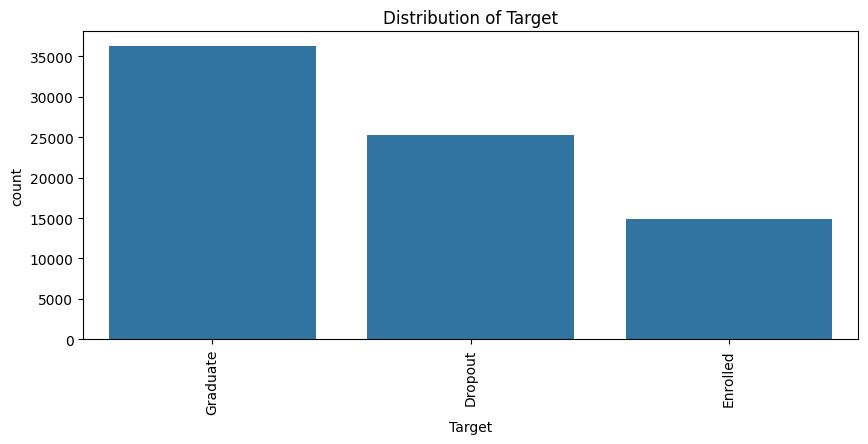

In [11]:
categorical_columns = df_train.select_dtypes(include=['object']).columns
for column in categorical_columns:
    plt.figure(figsize=(10, 4))
    sns.countplot(x=column, data=df_train)
    plt.title(f'Distribution of {column}')
    plt.xticks(rotation=90)
    plt.show()

### 설명 및 의미

| 문제 | 설명 | 의미 |
| --- | --- | --- |
| 클래스 불균형 | 데이터에는 졸업생이 중도 탈락자나 재학생보다 많아 클래스 불균형이 나타남. 이는 예측 모델을 만들 때 다수 클래스(졸업생)를 예측하는 경향을 가지게 할 수 있으므로 고려해야 함. | |
| 해결 기술 | - 재표본화: 소수 클래스를 오버샘플링하거나 다수 클래스를 언더샘플링함.  - 클래스 가중치 조정: 모델에서 각 클래스에 할당된 가중치를 조정하여 소수 클래스에 더 큰 중요성을 부여함.  - 특화된 알고리즘: SMOTE나 ADASYN과 같은 불균형 데이터를 처리하도록 설계된 알고리즘을 사용함. | |
| 분석 초점 | 졸업생 | 졸업에 기여하는 요인을 이해하면 성공적인 전략과 관행을 강화하는 데 도움이 될 수 있음.|
| 의미 | | |
| 중도 탈락자 |  | 중도 탈락자 분석을 통해 학생들이 왜 중도에 학업을 포기하는지, 그리고 중도 탈락률을 줄이기 위한 개입 방법을 파악할 수 있음.|
| 재학생 |  | 이 그룹을 모니터링함으로써 현재 시스템에 있는 학생들을 지원하기 위한 실시간 개입이 가능함. |


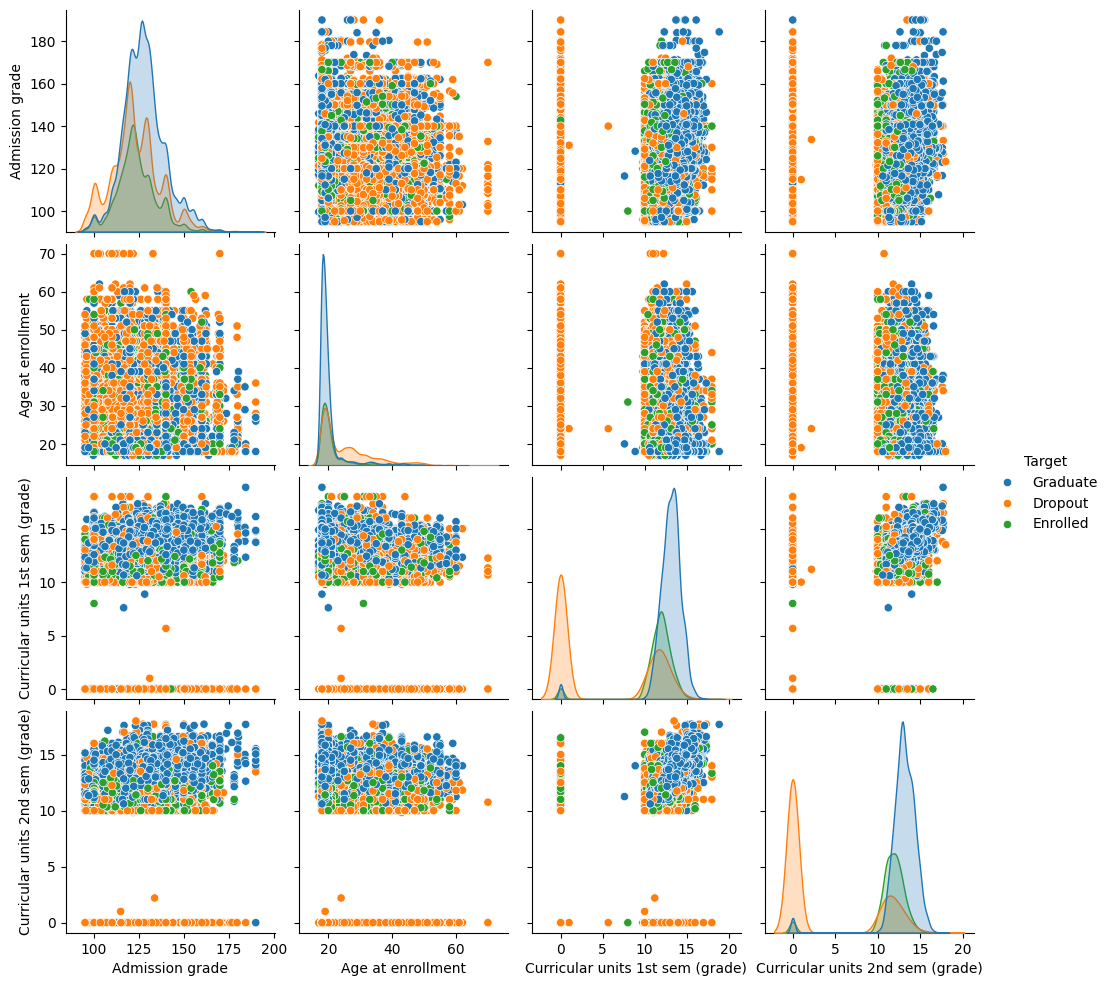

In [12]:
selected_features = ['Admission grade', 'Age at enrollment', 'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)', 'Target']
sns.pairplot(df_train[selected_features], hue='Target')
plt.show()

| 결과     | 관찰                                                                                                                                              |
|----------|---------------------------------------------------------------------------------------------------------------------------------------------------|
| 졸업생   | 입학 성적이 높은 학생들은 첫 학기 성적도 높은 경향이 있어, 입학 성적과 첫 학기 성적 사이에 긍정적인 상관관계가 있는 것으로 보임.                 |
| 중도 탈락자 | 첫 학기 성적이 낮은 학생들이나 성적이 없는 학생들이 주로 몰려 있어, 커리큘럼에서 어려움이나 다른 요인으로 인해 중도 탈락할 가능성이 있음을 나타낼 수 있음. |
| 재학생   | 이들은 다양하게 분포하지만 성적이 중간 정도인 학생들이 많아, 이들은 여전히 진행 중이지만 두드러지게 높은 성적을 보이지는 않을 수 있음.              |


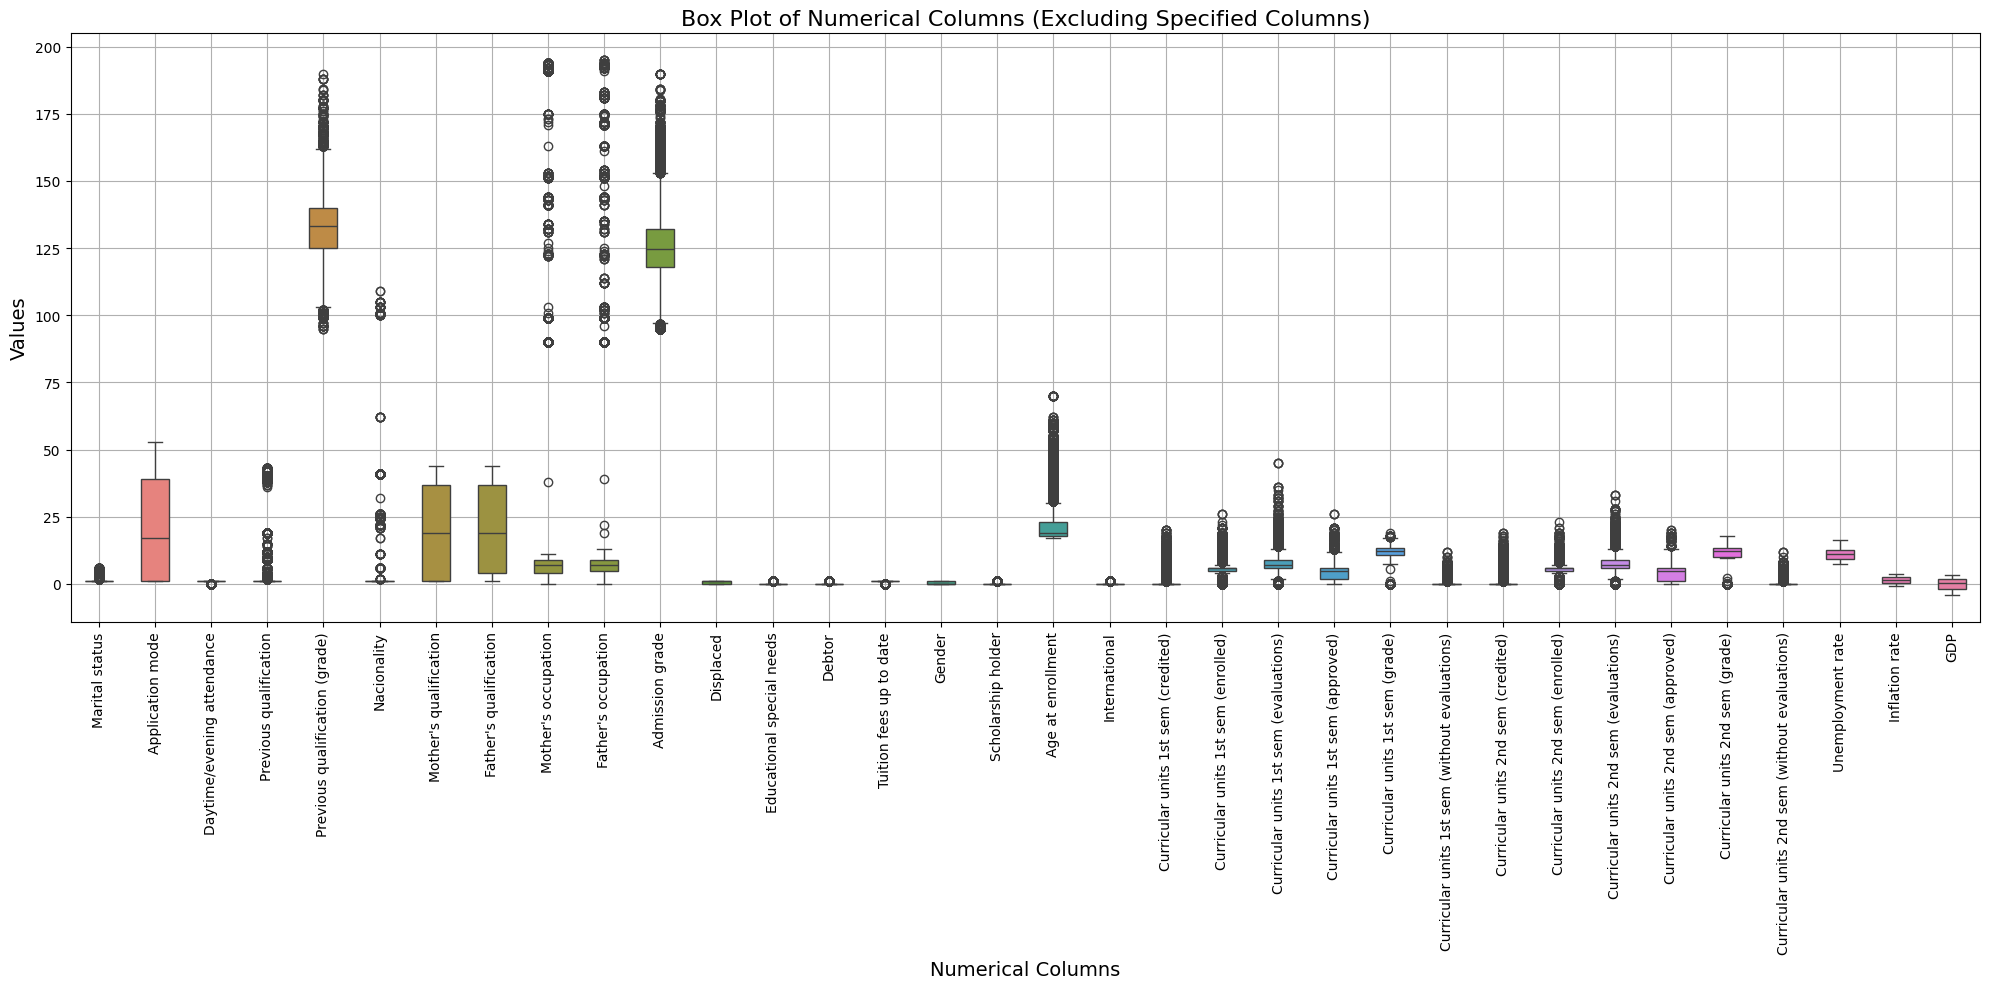

In [13]:
exclude_columns = ['id', 'Application order', 'Course']
numerical_cols = df_train.select_dtypes(include=['number']).drop(columns=exclude_columns).columns
plt.figure(figsize=(20, 10))
sns.boxplot(data=df_train[numerical_cols], orient='v', width=0.5)
plt.title('Box Plot of Numerical Columns (Excluding Specified Columns)', fontsize=16)
plt.xlabel('Numerical Columns', fontsize=14)
plt.ylabel('Values', fontsize=14)
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

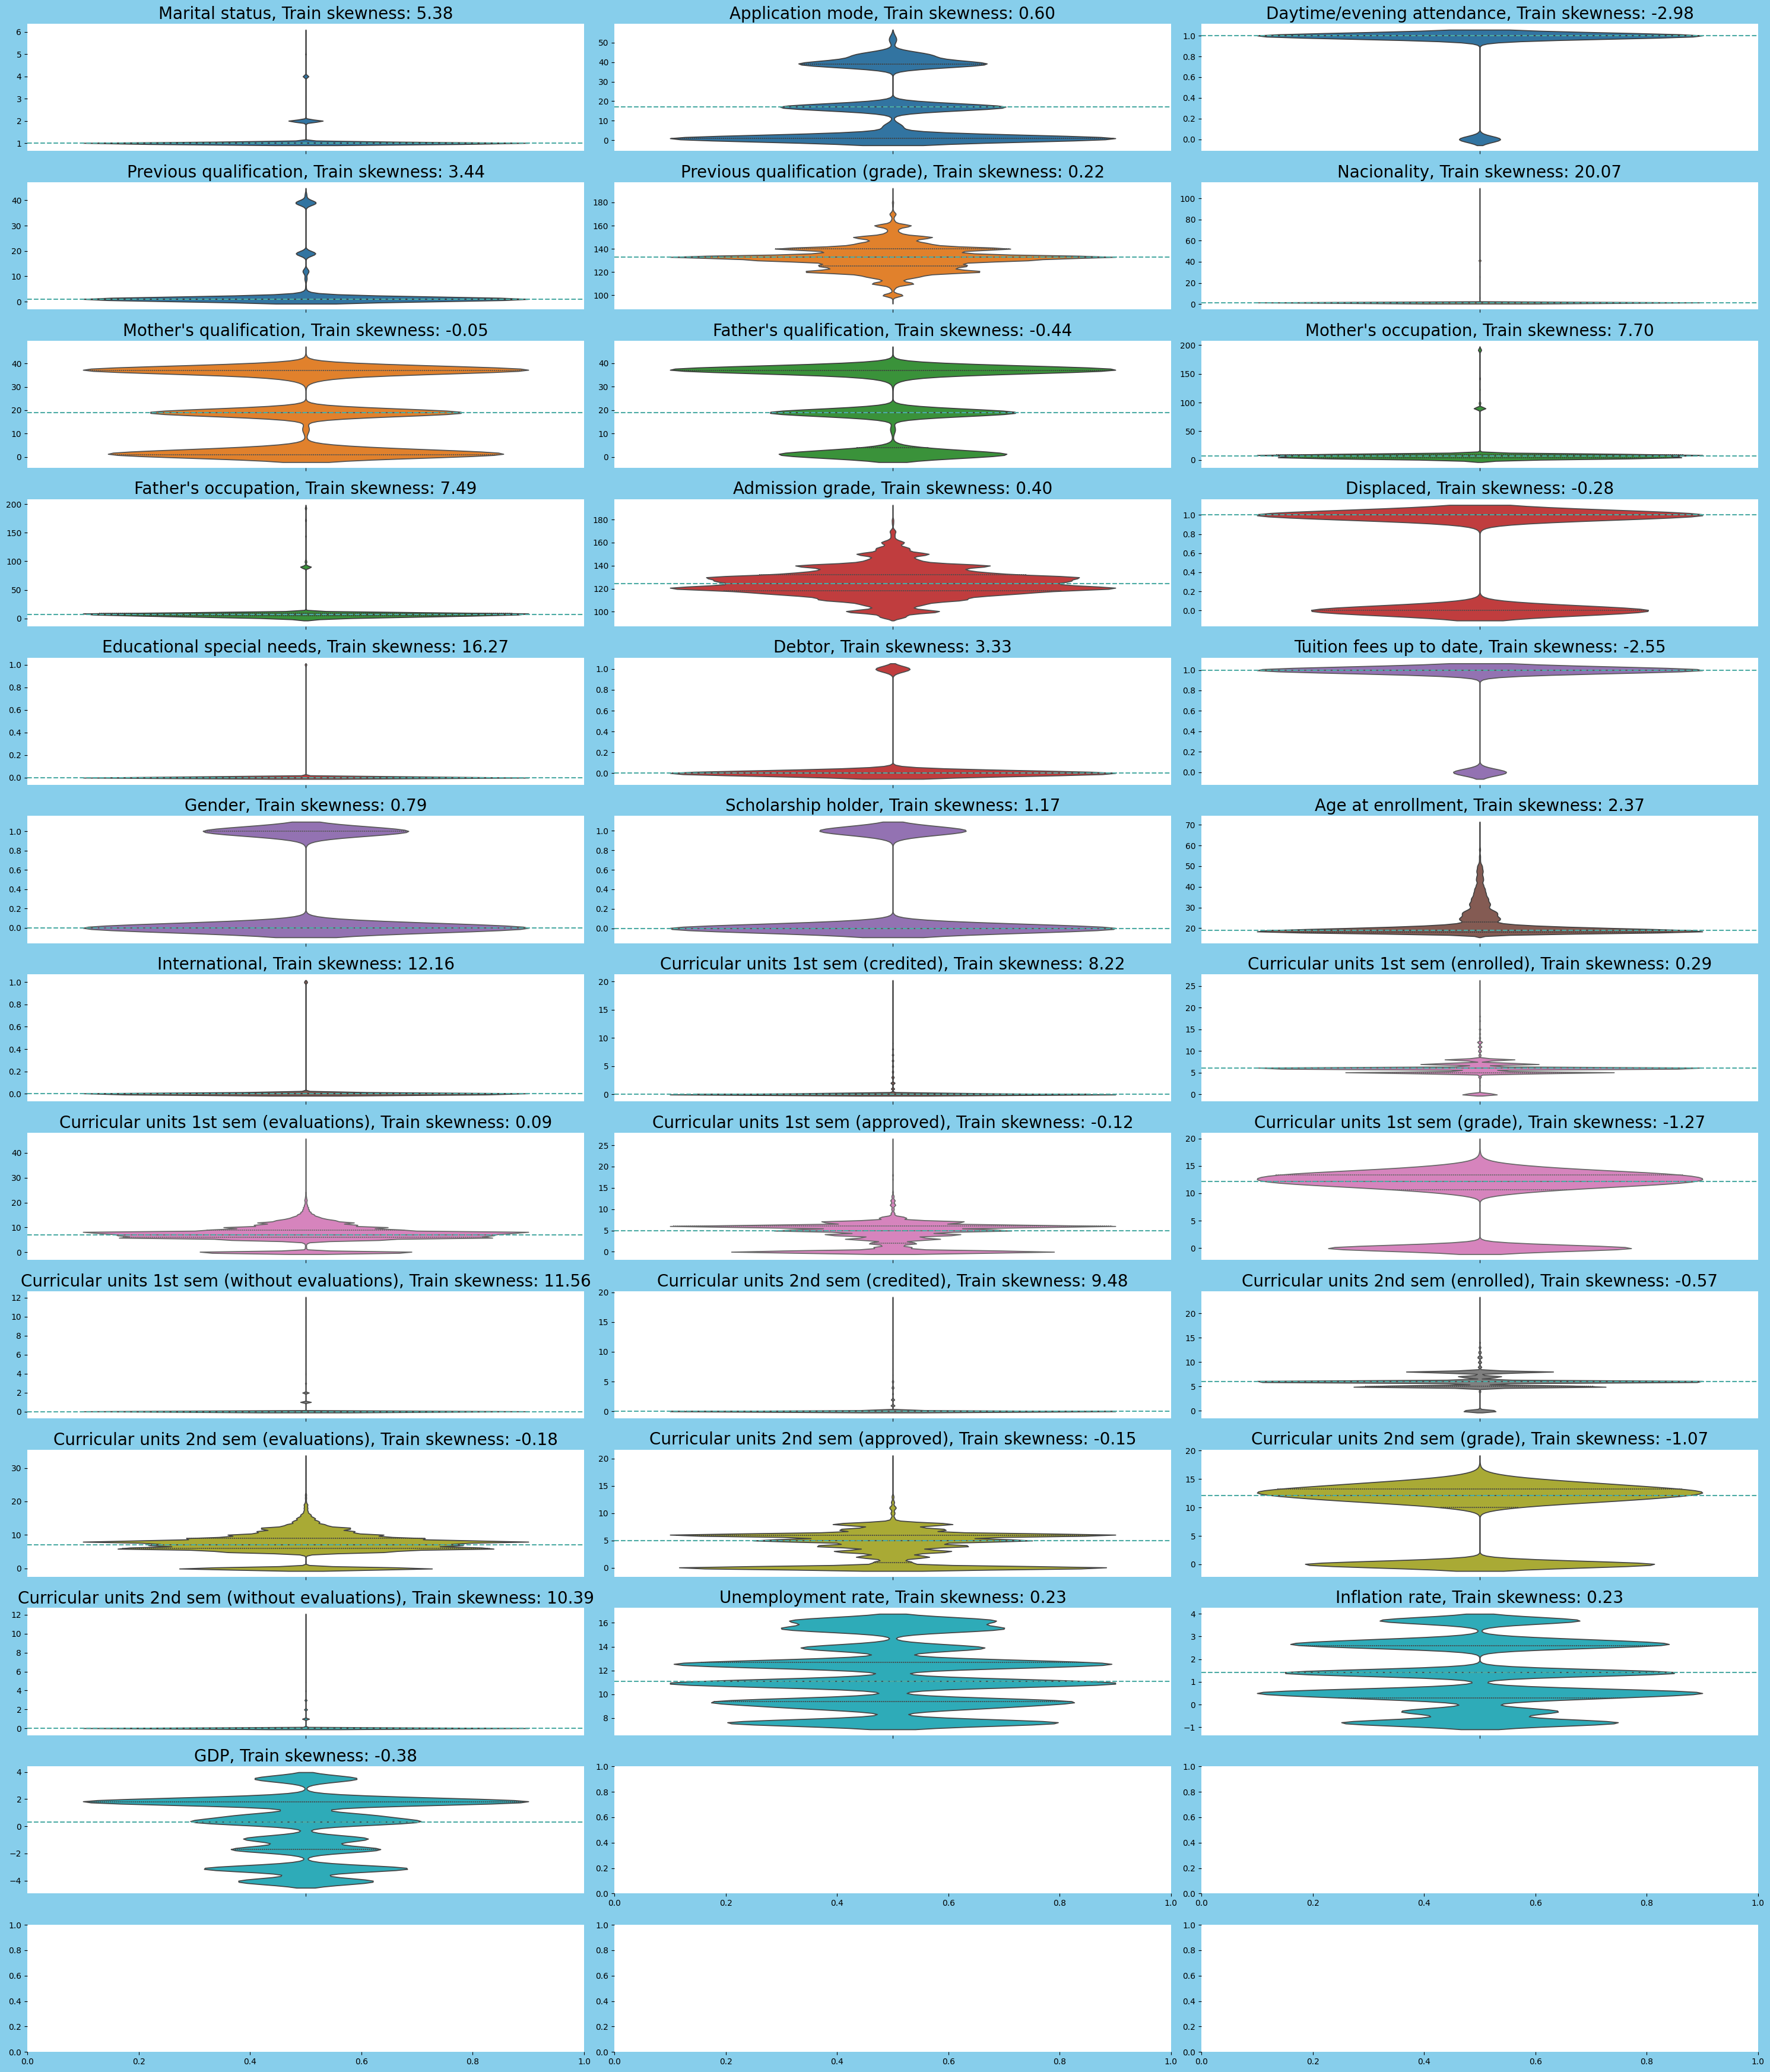

In [14]:
def violin_plot(train_dataset, columns_list, rows, cols):
    import matplotlib.cm as cm
    from itertools import cycle

    columns_list = [col for col in columns_list if col != 'id'] 
    fig, axs = plt.subplots(rows, cols, figsize=(30, 35))
    fig.subplots_adjust(hspace=2, top=0.4)  
    
    colors = cycle(cm.tab10(np.linspace(0, 1, len(columns_list))))  

    for i, col in enumerate(columns_list):
        color = next(colors) 
        sns.violinplot(y=train_dataset[col], ax=axs[i // cols, i % cols], color=color, inner='quartile')
        axs[i // cols, i % cols].set_title(f'{col}, Train skewness: {train_dataset[col].skew():.2f}', fontsize=20)
        axs[i // cols, i % cols].set_xlabel('')
        axs[i // cols, i % cols].set_ylabel('')
        axs[i // cols, i % cols].tick_params(axis='both', which='major', labelsize=10)
        median_train = train_dataset[col].median()
        axs[i // cols, i % cols].axhline(y=median_train, color='#4caba4', linestyle='--')
        
    #fig.suptitle('Violin Plot of Numeric Columns', fontsize=36)
    plt.tight_layout()
    plt.gcf().set_facecolor('skyblue')
    sns.despine(left=True, bottom=True)

violin_plot(train_dataset=df_train, columns_list=numerical_cols, rows=13, cols=3)


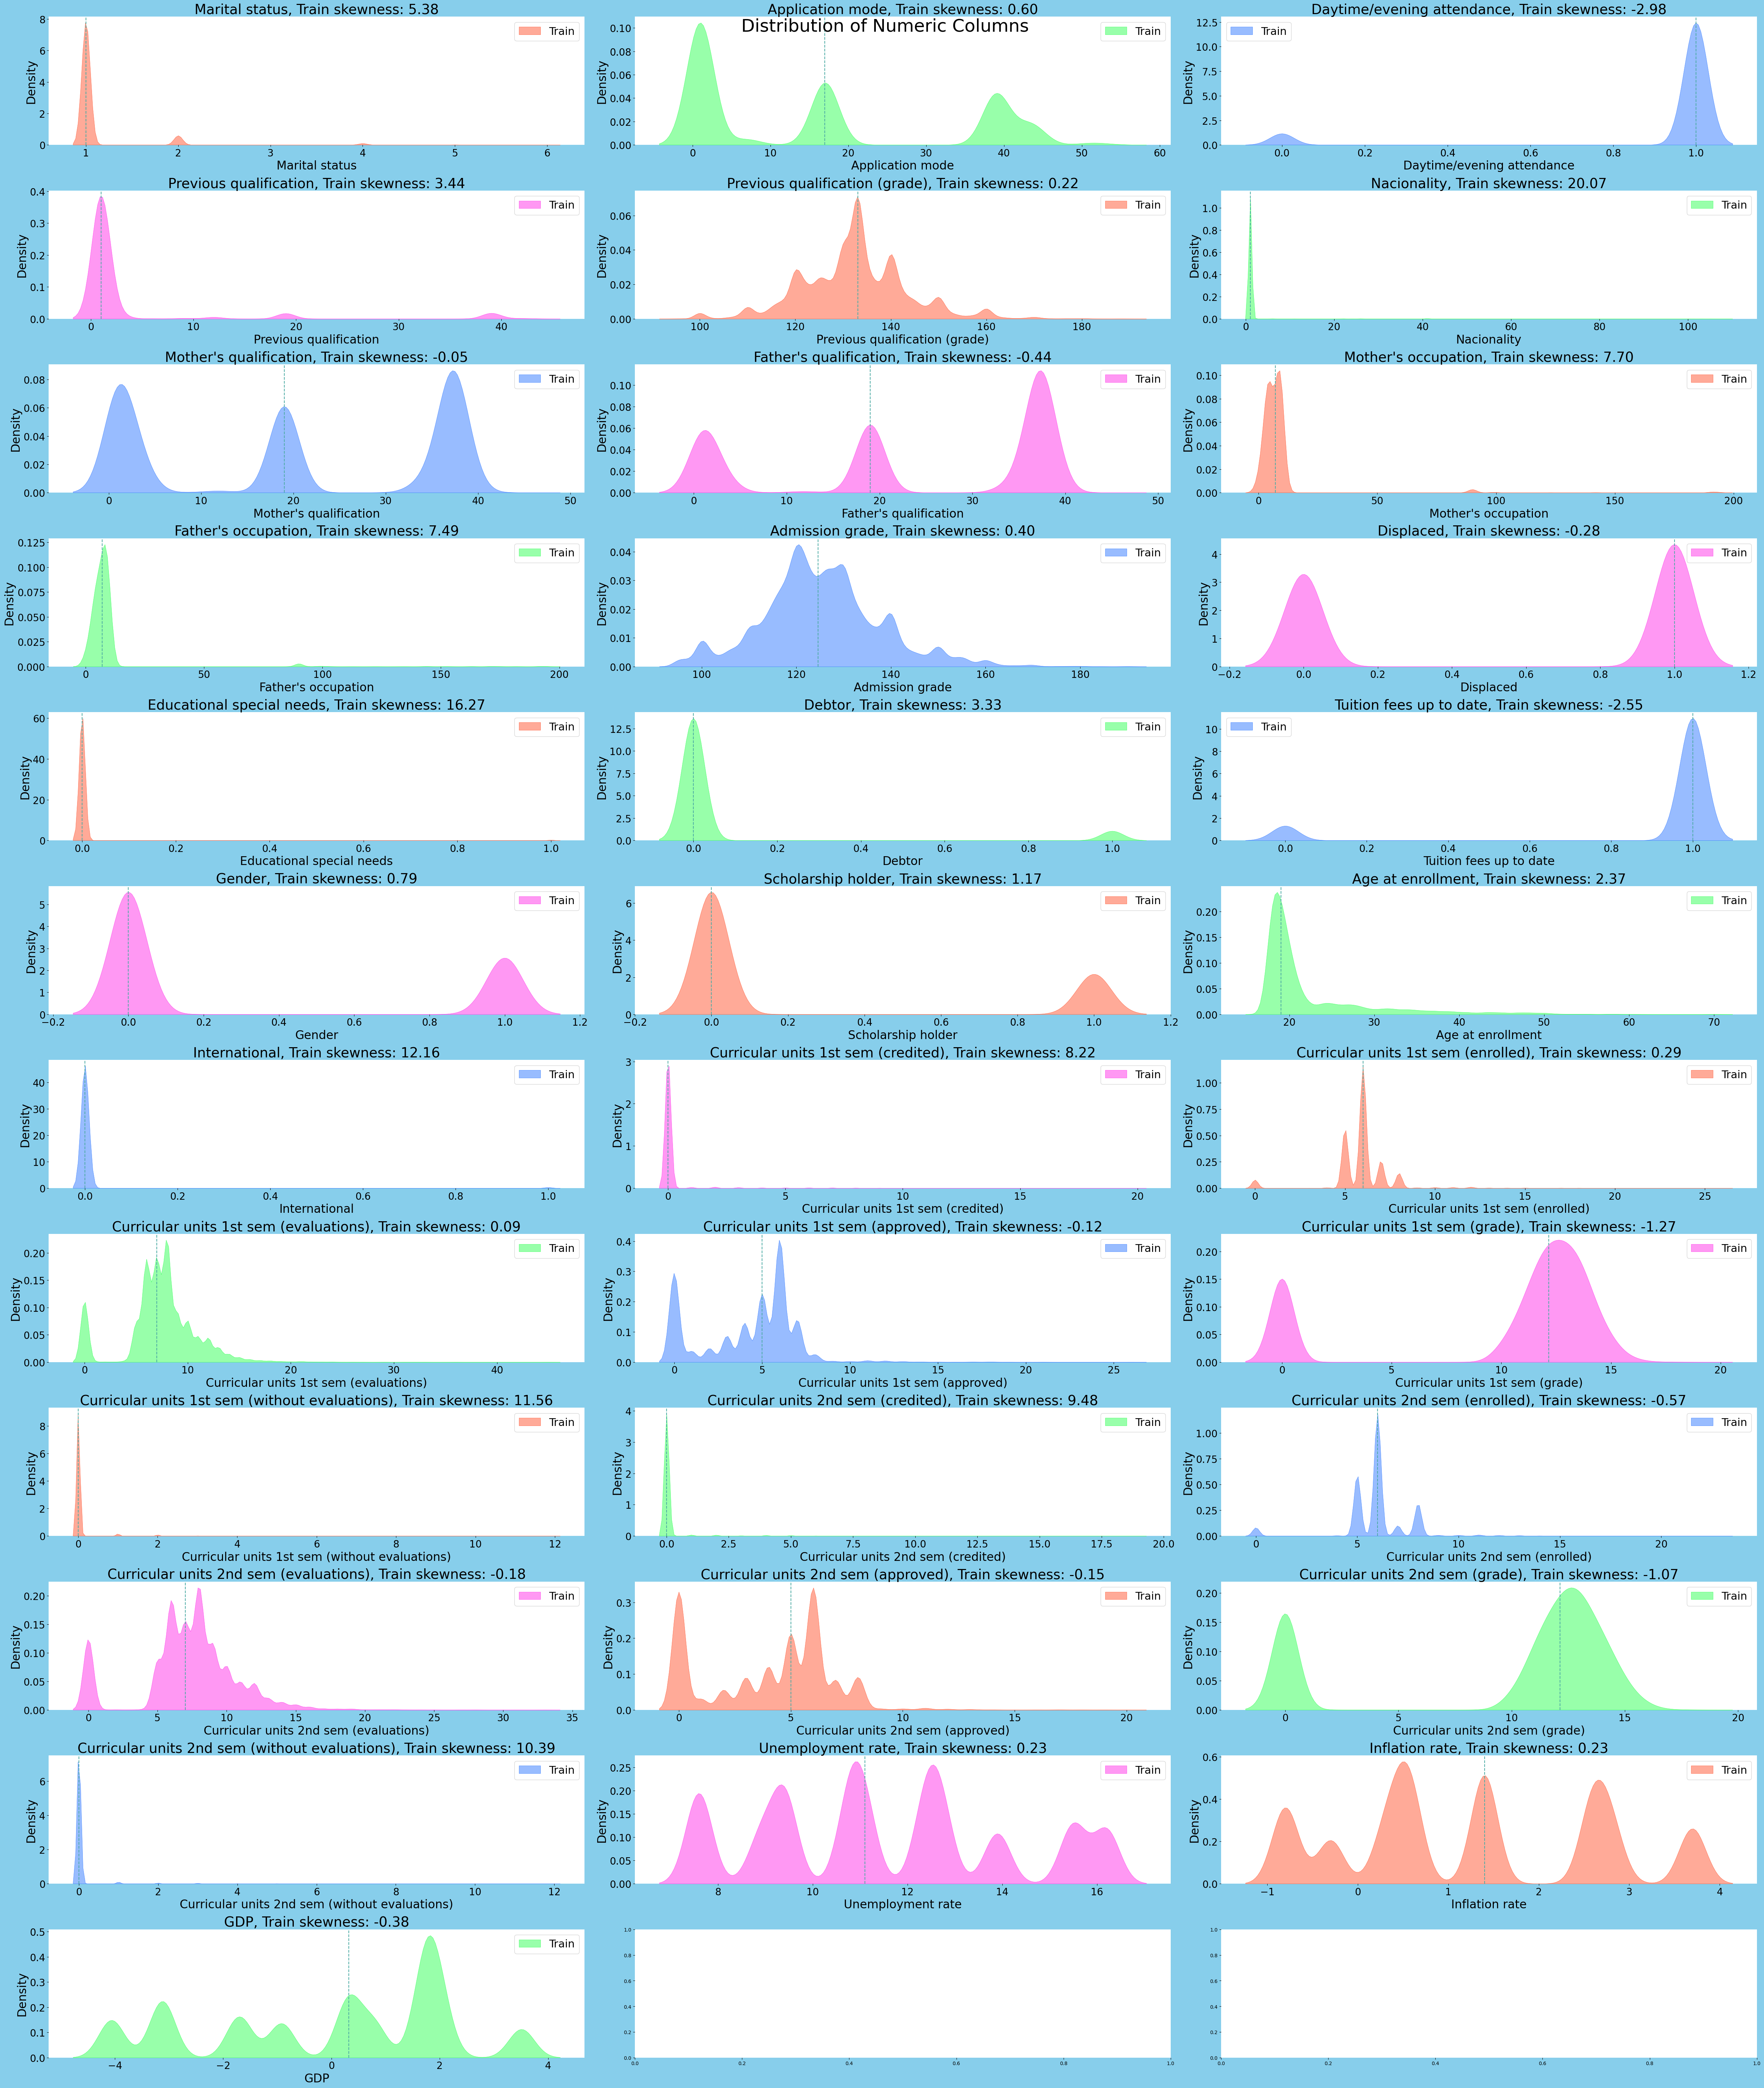

In [15]:
def dist(train_dataset, columns_list, rows, cols):
    columns_list = [col for col in columns_list if col != 'id'] 
    fig, axs = plt.subplots(rows, cols, figsize=(50, 60))  
    fig.subplots_adjust(hspace=1, wspace=1)  

    colors = ['#FF5733', '#33FF57', '#337AFF', '#FF33E9', '#FF5733', '#33FF57', '#337AFF', '#FF33E9', '#FF5733', '#33FF57', '#337AFF', '#FF33E9', '#FF5733', '#33FF57', '#337AFF', '#FF33E9', '#FF5733', '#33FF57', '#337AFF', '#FF33E9', '#FF5733', '#33FF57', '#337AFF', '#FF33E9', '#FF5733', '#33FF57', '#337AFF', '#FF33E9', '#FF5733', '#33FF57', '#337AFF', '#FF33E9', '#FF5733', '#33FF57', '#337AFF', '#FF33E9']
    
    for i, col in enumerate(columns_list):
        sns.kdeplot(train_dataset[col], ax=axs[i // cols, i % cols], fill=True, alpha=0.5, linewidth=0.5, color=colors[i], label='Train')
        axs[i // cols, i % cols].set_title(f'{col}, Train skewness: {train_dataset[col].skew():.2f}', fontsize=28) 
        axs[i // cols, i % cols].set_xlabel(col, fontsize=24)  
        axs[i // cols, i % cols].set_ylabel('Density', fontsize=24) 
        axs[i // cols, i % cols].legend(fontsize=22)  
        axs[i // cols, i % cols].tick_params(axis='both', which='major', labelsize=20)  
        median_train = train_dataset[col].median()
        axs[i // cols, i % cols].axvline(x=median_train, color='#4caba4', linestyle='--')
        
    fig.suptitle('Distribution of Numeric Columns', fontsize=36)  
    plt.tight_layout()
    plt.gcf().set_facecolor('skyblue')
    sns.despine(left=True, bottom=True) 

dist(train_dataset=df_train, columns_list=numerical_cols, rows=12, cols=3)




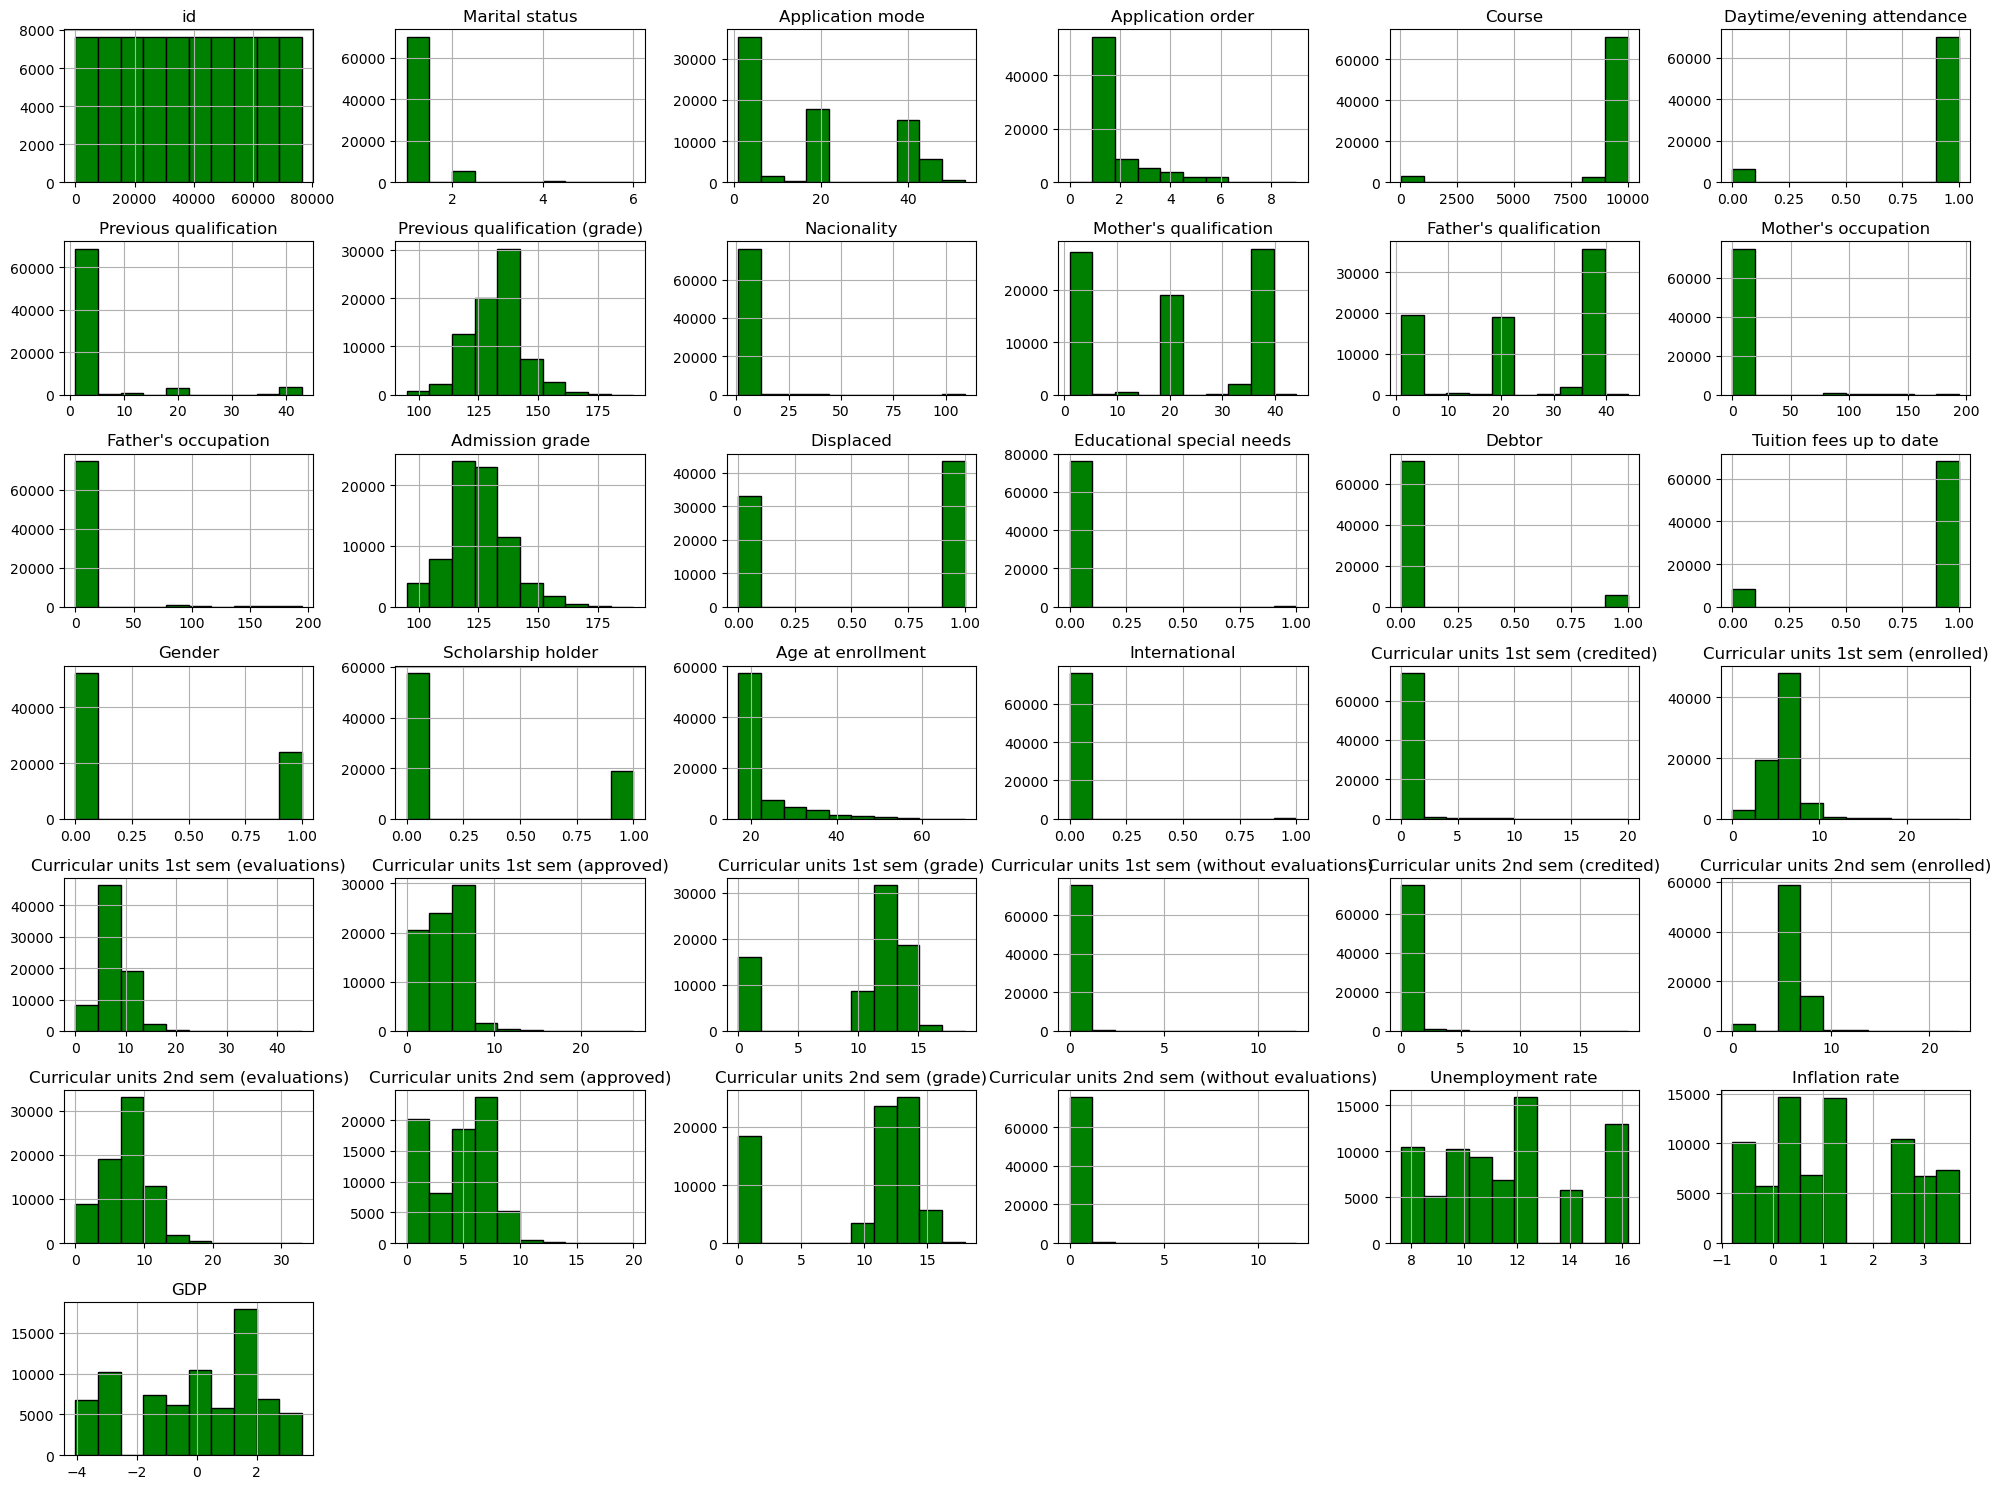

In [13]:
df_train.hist(figsize=(20, 15), color='green', edgecolor='black')
plt.gcf().set_facecolor('white')
plt.tight_layout()
plt.show()

In [16]:
label_encoder = LabelEncoder()
df_train['Target'] = label_encoder.fit_transform(df_train['Target'])

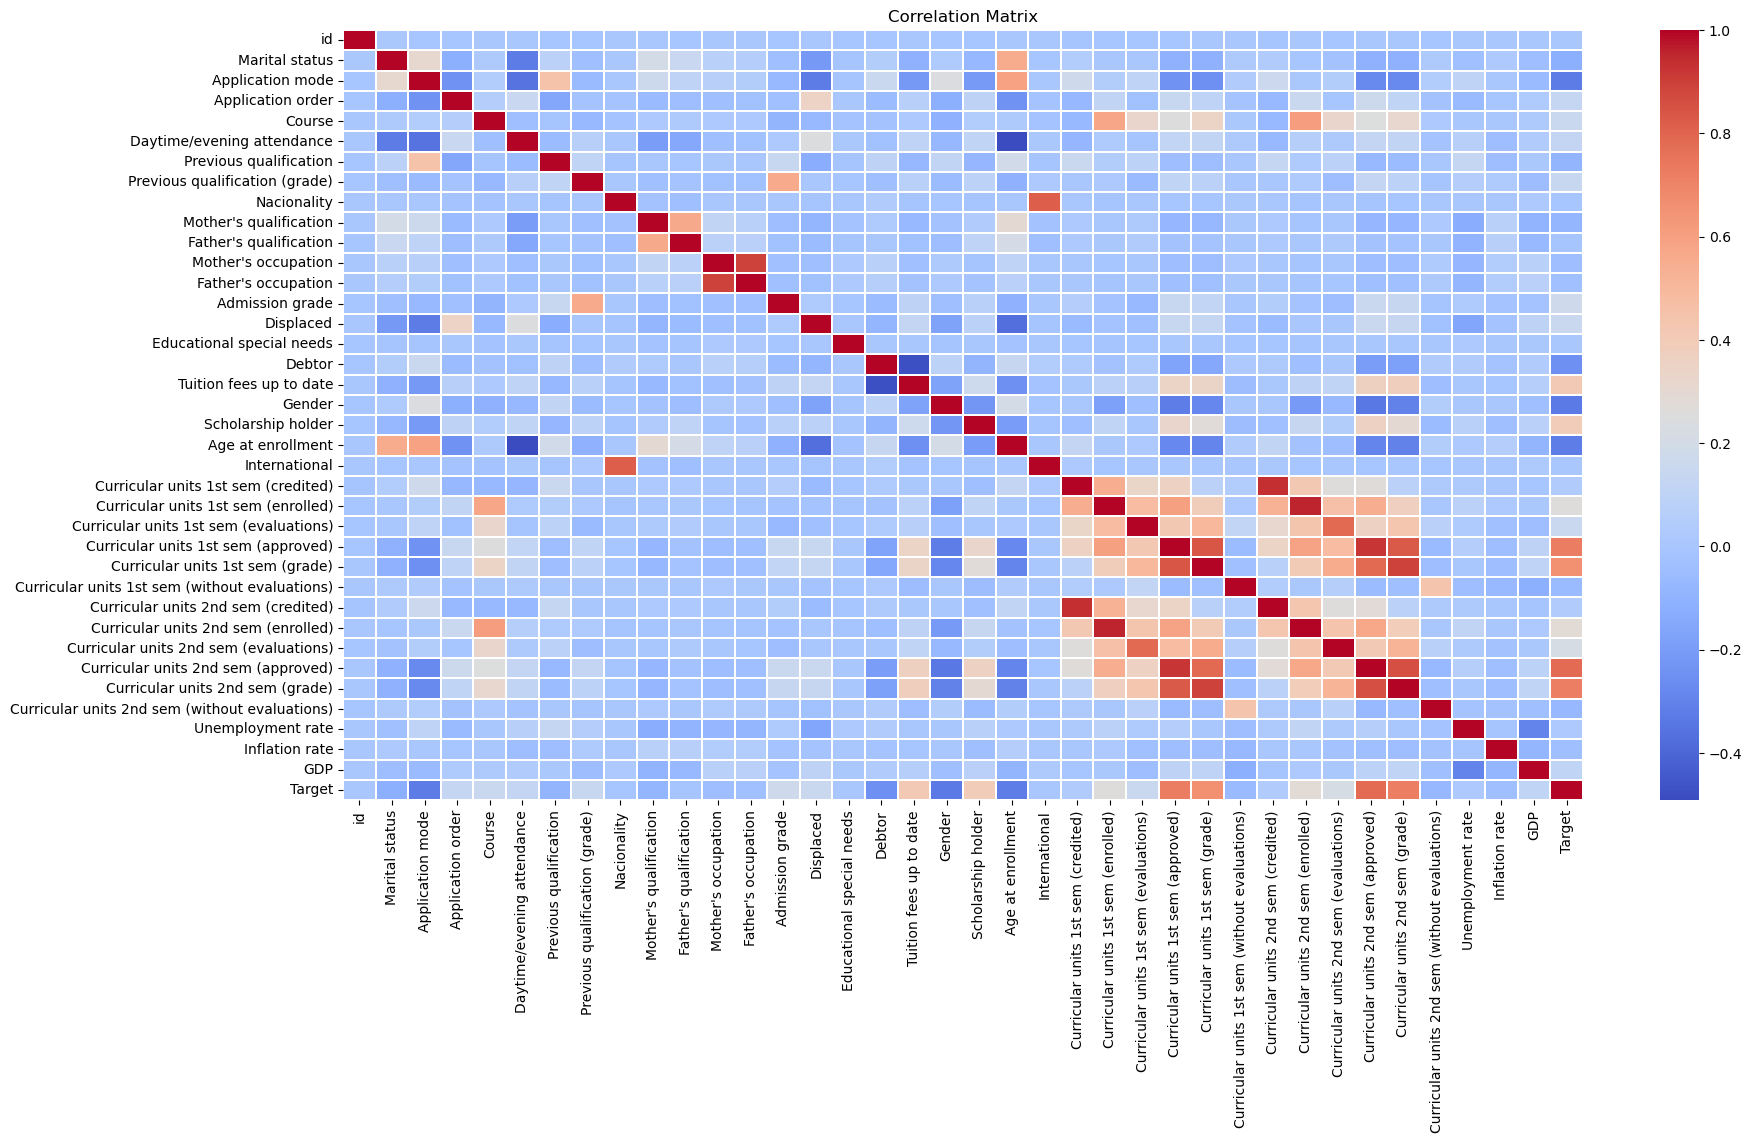

In [15]:
correlation_matrix = df_train.corr()
plt.figure(figsize=(20, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".1f", linewidths=0.1)
#plt.gcf().set_facecolor('skyblue')  
plt.title('Correlation Matrix')
plt.show()

| 문제                               | 조치                                     |
|------------------------------------|------------------------------------------|
| **학업 성적:**                     | 높은 성적은 졸업과 강한 상관관계가 있어, 성공 예측 요인으로 작용함.            |
| **입학 시 나이:**                  | 나이가 적을수록 높은 졸업률과 상관관계가 있음.                              |
| **거시경제 요소:**                 | 실업률, 인플레이션율, GDP와의 상관관계는 약하지만, 학생들의 학업 경험을 넓은 경제적 맥락에서 이해하는 데 도움을 줌. |
| **성별 및 장학금:**                | 성별은 약한 양의 상관관계를 보이며, 장학금은 부정적인 상관관계를 보여 특정 지원 영역을 시사. |
| **가정 배경:**                    | 부모의 학력은 직접적인 학생 성공과 연관성이 없지만, 결과에 영향을 미치며 가족의 지원의 중요성을 강조. |
| **결혼 상태:**                    | 특정 결혼 상태와 나이는 학업 성공에 영향을 미칠 수 있어, 다양한 인구 특성에 맞춘 지원이 필요함. |
| **결혼 상태와 이전 학력:**          | 결혼 상태와 이전 학력에서 범위를 벗어나는 이상치(결혼 상태에서 6329개, 이전 학력에서 9335개)를 제거하여 정확도를 높임. |
| **신청 순서와 코스:**              | 신청 순서와 코스에서 범위를 벗어나는 이상치(신청 순서에서 7895개, 코스에서 5371개)를 처리하여 데이터 무결성을 유지함. |
| **입학 시 나이:**                  | 학생들의 예상치를 벗어나는 이상치(8935개)를 제거함.                           |
| **교과 단위 (1학기 및 2학기):**     | 평가, 등록 및 승인과 관련된 이상치를 분석하여 일관성을 유지함.                  |
| **교과 단위 성적:**                | 이상치를 처리하여 정확한 데이터 표현을 보장함.                                |
| **상관된 열:**                     | 다중공선성을 피하기 위해 각 쌍 중 하나를 제거하는 것을 고려함.                   |
| **이전 학력 성적:**                | 예상된 성적 범위를 벗어나는 이상치(1364개)를 제거함.                           |
| **직업 열:**                       | "어머니의 직업"과 "아버지의 직업"에서 중요한 이상치를 제거하여 데이터의 유효성을 보장함. |
| **평가 없는 교과 단위:**            | 이상치를 처리하여 학생 평가의 정확성을 보장함.                                  |
| **문제 없는 열:**                   | 여러 열에서 데이터 품질 문제가 없으며, 직접 분석에 사용할 수 있음.               |


In [17]:
df_test.isnull().sum()

id                                                0
Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship 

In [43]:
df_train = pd.read_csv('data/train.csv')
df_test  = pd.read_csv('data/train.csv')
df_sub = pd.read_csv('data/train.csv')

In [19]:
df_train.head()

,id,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,0,1,1,1,9238,1,1,126.0,1,1,...,0,6,7,6,12.428571,0,11.1,0.6,2.02,Graduate
1,1,1,17,1,9238,1,1,125.0,1,19,...,0,6,9,0,0.000000,0,11.1,0.6,2.02,Dropout
2,2,1,17,2,9254,1,1,137.0,1,3,...,0,6,0,0,0.000000,0,16.2,0.3,-0.92,Dropout
3,3,1,1,3,9500,1,1,131.0,1,19,...,0,8,11,7,12.820000,0,11.1,0.6,2.02,Enrolled
4,4,1,1,2,9500,1,1,132.0,1,19,...,0,7,12,6,12.933333,0,7.6,2.6,0.32,Graduate


### 피쳐 엔지니어링

In [29]:
from scipy.stats import skew

def handle_skewed_columns(df):
    numerical_features = df.select_dtypes(include=[np.number])
    skewness = numerical_features.apply(lambda x: skew(x.dropna()))
    skewed_features = skewness[abs(skewness) > 1] 

    for col in skewed_features.index:
        if df[col].min() > -1: 
            df[f'{col}_log'] = np.log1p(df[col])
    return df


def add_curriculum_interaction_features(df):
    df['Curriculum_interaction_1st_sem'] = df['Curricular units 1st sem (credited)'] * df['Curricular units 1st sem (enrolled)'] * df['Curricular units 1st sem (evaluations)'] * df['Curricular units 1st sem (approved)']
    df['Curriculum_interaction_2nd_sem'] = df['Curricular units 2nd sem (credited)'] * df['Curricular units 2nd sem (enrolled)'] * df['Curricular units 2nd sem (evaluations)'] * df['Curricular units 2nd sem (approved)']

def add_grade_interaction_features(df):
    df['Grade_interaction_1st_sem'] = df['Admission grade'] * df['Curricular units 1st sem (grade)']
    df['Grade_interaction_2nd_sem'] = df['Admission grade'] * df['Curricular units 2nd sem (grade)']

def add_age_interaction_features(df):
    df['Age_interaction'] = df['Age at enrollment'] * df['Previous qualification (grade)']  

def add_economic_interaction_features(df):    
    df['Economic_interaction_add'] = df['Unemployment rate'] + df['Inflation rate'] + df['GDP']
    df['Economic_interaction_sub'] = df['Unemployment rate'] - df['Inflation rate'] - df['GDP']  
    df['Economic_interaction_div1'] = df['Unemployment rate'] / (df['Inflation rate'] + 1e-6)
    df['Economic_interaction_div2'] = df['Inflation rate'] / (df['GDP'] + 1e-6)
    df['Economic_interaction_div3'] = df['GDP'] / (df['Unemployment rate'] + 1e-6)   
    df['Economic_interaction_comb1'] = (df['Unemployment rate'] + df['Inflation rate']) * df['GDP']
    df['Economic_interaction_comb2'] = (df['Unemployment rate'] * df['Inflation rate']) + df['GDP']
    df['Economic_interaction_exp1'] = df['Unemployment rate'] * df['Inflation rate']
    df['Economic_interaction_exp2'] = df['GDP'] * df['Unemployment rate']
    df['Economic_interaction_exp3'] = df['GDP'] * df['Inflation rate']
    df['Economic_interaction_log1'] = np.log1p(df['Unemployment rate']) + np.log1p(df['Inflation rate']) + np.log1p(df['GDP'])
    df['Economic_interaction'] = (df['Unemployment rate'] * df['Inflation rate'] * df['GDP'])
    df['Economic_interaction_sqrt1'] = np.sqrt(df['Unemployment rate']) + np.sqrt(df['Inflation rate']) + np.sqrt(df['GDP'])
    df['Economic_interaction_sqrt2'] = np.sqrt(df['Unemployment rate'] * df['Inflation rate'] * df['GDP'])
    df['Economic_interaction_poly1'] = df['Unemployment rate']**2 + df['Inflation rate']**2 + df['GDP']**2
    df['Economic_interaction_poly2'] = (df['Unemployment rate'] * df['Inflation rate']) + (df['Inflation rate'] * df['GDP']) + (df['GDP'] * df['Unemployment rate'])
    return df     



def add_qualification_interaction_features(df):
    df['Qualification_interaction'] = df['Previous qualification'] * df['Admission grade']
    df['Course_interaction'] = df['Previous qualification'] * df['Course']
    
def add_occupation_interaction_features(df):
    df["Occupation_interaction"] = df["Mother's occupation"] * df["Father's occupation"]

def add_enrollment_evaluation_interaction_features(df):
    df['Enrollment_evaluation_interaction_1st_sem'] = df['Curricular units 1st sem (enrolled)'] * df['Curricular units 1st sem (evaluations)']
    df['Enrollment_evaluation_interaction_2nd_sem'] = df['Curricular units 2nd sem (enrolled)'] * df['Curricular units 2nd sem (evaluations)']

def add_gender_marital_interaction_features(df):
    df['Gender_marital_interaction'] = df['Gender'] * df['Marital status']

def add_tuition_scholarship_interaction_features(df):
    df['Tuition_scholarship_interaction'] = df['Tuition fees up to date'] * df['Scholarship holder']

def feature_engineer_train(df_train):    
    df_train = handle_skewed_columns(df_train)   
    
    add_curriculum_interaction_features(df_train)
    add_grade_interaction_features(df_train)
    add_age_interaction_features(df_train)
    add_economic_interaction_features(df_train)
    add_qualification_interaction_features(df_train)
    add_occupation_interaction_features(df_train)
    add_enrollment_evaluation_interaction_features(df_train)
    add_gender_marital_interaction_features(df_train)
    add_tuition_scholarship_interaction_features(df_train)
    return df_train

def feature_engineer_test(df_test):    
    df_test = handle_skewed_columns(df_test)  
   
    add_curriculum_interaction_features(df_test)
    add_grade_interaction_features(df_test)
    add_age_interaction_features(df_test)
    add_economic_interaction_features(df_test)
    add_qualification_interaction_features(df_test)
    add_occupation_interaction_features(df_test)
    add_enrollment_evaluation_interaction_features(df_test)
    add_gender_marital_interaction_features(df_test)
    add_tuition_scholarship_interaction_features(df_test)
    return df_test




In [30]:
df_train = feature_engineer_train(df_train)
df_test = feature_engineer_test(df_test)

/home/a202192010/.local/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/a202192010/.local/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/a202192010/.local/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/a202192010/.local/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/a202192010/.local/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/a202192010/.local/lib/python3.8/site-packages/pandas/core/arraylike

In [31]:
def add_interaction_features(df):
    df['Application_mode_x_Application_order'] = df['Application mode'] * df['Application order']
    df['Course_x_Curricular_units_1st_sem_enrolled'] = df['Course'] * df['Curricular units 1st sem (enrolled)']
    df['Daytime_evening_attendance_x_Age_at_enrollment'] = df['Daytime/evening attendance'] * df['Age at enrollment']
    df['Previous_qualification_grade_x_Admission_grade'] = df['Previous qualification (grade)'] * df['Admission grade']
    df['Displaced_x_Curricular_units_1st_sem_approved'] = df['Displaced'] * df['Curricular units 1st sem (approved)']
    df['Scholarship_holder_x_Tuition_fees_up_to_date'] = df['Scholarship holder'] * df['Tuition fees up to date']
    df['Curricular_units_1st_sem_approved_x_Curricular_units_2nd_sem_approved'] = df['Curricular units 1st sem (approved)'] * df['Curricular units 2nd sem (approved)']
    df['Unemployment_rate_x_Inflation_rate'] = df['Unemployment rate'] * df['Inflation rate']
    return df

In [32]:
df_train = add_interaction_features(df_train)
df_test = add_interaction_features(df_test)

In [33]:
df_train.shape

(76518, 93)

In [34]:
df_train.to_csv('trainfeature.csv',index=False)
df_test.to_csv('testfeature.csv',index=False)

In [44]:
df_train['Target']

0        Graduate
1         Dropout
2         Dropout
3        Enrolled
4        Graduate
           ...   
76513    Graduate
76514    Graduate
76515    Enrolled
76516     Dropout
76517    Graduate
Name: Target, Length: 76518, dtype: object

In [45]:
label_encoder = LabelEncoder()
df_train['Target'] = label_encoder.fit_transform(df_train['Target'])
#y = label_encoder.fit_transform(y)

In [46]:
y = df_train['Target'] 
df_train = df_train.drop(['Target'],axis=1)
#df_train = df_train_cleaned

### 모델링

In [47]:
train = df_train

In [48]:
df_test1 =df_test

### LGB , K-folds

- 3가지의 좋은 성능을 내는 파라메터를 조사를 통하여 참고하였음

In [71]:
lgb_params1 = {"boosting_type": "gbdt","objective": "multiclass","metric": "multi_logloss", 'num_class':3,      
                         'n_estimators': 1024,
                         'reg_alpha': 0.1, 'reg_lambda': 10, 
                         'colsample_bytree': 0.8, 'subsample': 0.8,
                         'learning_rate': 0.05, 'num_leaves': 64, 'min_child_samples': 62,
                         'max_bin':245, "extra_trees": True,
                         'verbosity': 1

                    }

lgb_params2 = {"boosting_type": "gbdt","objective": "multiclass","metric": "multi_logloss", 'num_class':3,      
     'n_estimators': 1024,
     'reg_alpha': 2.6756579164398144, 'reg_lambda': 1.6187614490530422, 
     'colsample_bytree': 0.7, 'subsample': 0.7,
     'learning_rate': 0.030479973315991688, 'num_leaves': 50, 'min_child_samples': 62,
     'max_bin':245,
     'verbosity': 1

}



lgb_params3 = {'n_estimators': 8000, 
          'num_class': 3,
          'boosting_type': 'gbdt',
          'objective': 'multiclass',
          'metric': 'multi_logloss',
          'verbosity': 1,
          'random_state': 99, 
          'reg_alpha': 1.7878527151970849, 
          'reg_lambda': 1.391543710164331, 
          'colsample_bytree': 0.5, 
          'subsample': 0.5, 
          'learning_rate': 0.04, 
          'max_depth': 20, 
          'num_leaves': 70, 
          'min_child_samples': 40, 
          'min_data_per_groups': 16
         }

n_splits = 10
kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)


lgbm_predictions1 = np.zeros(len(train))
lgbm_predictions2 = np.zeros(len(train))
lgbm_predictions3 = np.zeros(len(train))

lgbm_test_predictions1 = np.zeros((len(df_test1), len(np.unique(y))))
lgbm_test_predictions2 = np.zeros((len(df_test1), len(np.unique(y))))
lgbm_test_predictions3 = np.zeros((len(df_test1), len(np.unique(y))))

num_classes = len(np.unique(y))

def train_predict(params, train, y, df_test1, n_splits, kf):
    fold_predictions = np.zeros(len(train))
    fold_test_predictions = np.zeros((len(df_test1), num_classes))
    feature_importances = np.zeros(train.shape[1])

    for fold, (train_idx, val_idx) in enumerate(kf.split(train, y)):
        X_train, X_val = train.iloc[train_idx], train.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        lgbm_model = LGBMClassifier(**params)

        lgbm_model.fit(X_train, y_train,
                       eval_set=[(X_val, y_val)])

        lgbm_fold_preds = lgbm_model.predict(X_val)
        lgbm_fold_test_preds = lgbm_model.predict_proba(df_test1)

        fold_predictions[val_idx] = lgbm_fold_preds
        fold_test_predictions += lgbm_fold_test_preds / n_splits

        feature_importances += lgbm_model.feature_importances_

    return fold_predictions, fold_test_predictions, feature_importances


In [72]:
preds3, test_preds3, feat_imports3 = train_predict(lgb_params3, train, y, df_test1, n_splits, kf)

ensemble_train_preds3 = np.array([preds3]).T
ensemble_train_preds3 = mode(ensemble_train_preds3, axis=1).mode.flatten()

ensemble_test_preds3 = (test_preds3) 

ensemble_test_preds_labels3 = np.argmax(ensemble_test_preds3, axis=1)

overall_metric_lgbm = accuracy_score(y, ensemble_train_preds3)
print("Overall Accuracy (Ensemble LGBM):", overall_metric_lgbm)

[LightGBM] [Warning] Unknown parameter: min_data_per_groups
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Unknown parameter: min_data_per_groups
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.187312 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1633
[LightGBM] [Info] Number of data points in the train set: 68866, number of used features: 37
[LightGBM] [Warning] Unknown parameter: min_data_per_groups
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score -1.106850
[LightGBM] [Info] Start training from score -1.633481
[LightGBM] [Info] Start training from score -0.746226
Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/usr/local/lib/python3.8/dist-packages/IPython/core/interactiveshell.py", line 3378, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_3901108/2856943834.py", line 1, in <module>
    preds3, test_preds3, feat_imports3 = train_predict(lgb_params3, train, y, df_test1, n_splits, kf)
  File "/tmp/ipykernel_3901108/3379486562.py", line 66, in train_predict
    lgbm_model.fit(X_train, y_train,
  File "/home/a202192010/.local/lib/python3.8/site-packages/lightgbm/sklearn.py", line 1187, in fit
    )
  File "/home/a202192010/.local/lib/python3.8/site-packages/lightgbm/sklearn.py", line 885, in fit
    label=_y,
  File "/home/a202192010/.local/lib/python3.8/site-packages/lightgbm/engine.py", line 276, in train
    callbacks_after_iter_set = callbacks_set - callbacks_before_iter_set
  File "/home/a202192010/.local/lib/python3.8/site-packages/lightgbm/basic.py", line 3891, in update
KeyboardInterrupt

During handling

In [ ]:
preds2, test_preds2, feat_imports2 = train_predict(lgb_params2, train, y, df_test1, n_splits, kf)

ensemble_train_preds2 = np.array([preds2]).T
ensemble_train_preds2 = mode(ensemble_train_preds2, axis=1).mode.flatten()

ensemble_test_preds2 = (test_preds2) 

ensemble_test_preds_labels2 = np.argmax(ensemble_test_preds2, axis=1)

overall_metric_lgbm = accuracy_score(y, ensemble_train_preds2)
print("Overall Accuracy (Ensemble LGBM):", overall_metric_lgbm)

In [ ]:
preds1, test_preds1, feat_imports1 = train_predict(lgb_params1, train, y, df_test1, n_splits, kf)

ensemble_train_preds1 = np.array([preds1]).T
ensemble_train_preds1 = mode(ensemble_train_preds1, axis=1).mode.flatten()

ensemble_test_preds1 = (test_preds1) 

ensemble_test_preds_labels1 = np.argmax(ensemble_test_preds1, axis=1)

overall_metric_lgbm = accuracy_score(y, ensemble_train_preds1)
print("Overall Accuracy (Ensemble LGBM):", overall_metric_lgbm)

In [32]:
def new_stars(df_train,y,df_test,params):    
    
    n_split=10
    test_preds = np.zeros((len(df_test),3))
    val_preds = np.zeros((len(df_train),3))    
    
    cv = KFold(n_split, shuffle=True, random_state=42)
    
    for fold, (train_ind, valid_ind) in enumerate(cv.split(df_train,y)):
        
        X_train, X_val = train.iloc[train_ind], train.iloc[valid_ind]
        y_train, y_val = y.iloc[train_ind], y.iloc[valid_ind]  
        
        
        model = lgb.LGBMClassifier(**params)
        model.fit(X_train, y_train,
                    eval_set=[(X_val, y_val)],
                    callbacks=[lgb.early_stopping(stopping_rounds=45)]) 
        
        y_pred_trn=model.predict_proba(X_train)
        y_pred_val=model.predict_proba(X_val)          
        test_preds += model.predict_proba(df_test1)/n_split
        val_preds[valid_ind] = model.predict_proba(X_val)
           
        
    return val_preds, test_preds

In [33]:
val_preds, test_preds=new_stars(train,y,df_test1,lgb_params3)

[LightGBM] [Warning] Unknown parameter: min_data_per_groups
Training until validation scores don't improve for 45 rounds
Early stopping, best iteration is:
[466]	valid_0's multi_logloss: 0.428405
[LightGBM] [Warning] Unknown parameter: min_data_per_groups
Training until validation scores don't improve for 45 rounds
Early stopping, best iteration is:
[390]	valid_0's multi_logloss: 0.418458
[LightGBM] [Warning] Unknown parameter: min_data_per_groups
Training until validation scores don't improve for 45 rounds
Early stopping, best iteration is:
[500]	valid_0's multi_logloss: 0.42304
[LightGBM] [Warning] Unknown parameter: min_data_per_groups
Training until validation scores don't improve for 45 rounds
Early stopping, best iteration is:
[526]	valid_0's multi_logloss: 0.433074
[LightGBM] [Warning] Unknown parameter: min_data_per_groups
Training until validation scores don't improve for 45 rounds
Early stopping, best iteration is:
[437]	valid_0's multi_logloss: 0.438456
[LightGBM] [Warning] 

In [34]:
val_preds_out = np.argmax(val_preds, axis=1)
accuracy_score(y,val_preds_out)

0.832707370709891

In [35]:
y_test=np.argmax(test_preds, axis=1)
y_test

array([0, 2, 2, ..., 0, 0, 0])

In [36]:
ypred = ensemble_test_preds_labels3*0.6+ensemble_test_preds_labels1*0.4#+#ensemble_test_preds_labels2*0.025+ensemble_test_preds_labels1*0.025)

In [37]:
classi = np.round(ypred).astype(int)
categorical_predictions = label_encoder.inverse_transform(classi)

In [38]:
categorical_predictions

array(['Dropout', 'Graduate', 'Graduate', ..., 'Dropout', 'Dropout',
       'Dropout'], dtype=object)

In [39]:
df_sub['Target'] =categorical_predictions

In [40]:
df_sub.head()

,id,Target
0,76518,Dropout
1,76519,Graduate
2,76520,Graduate
3,76521,Graduate
4,76522,Enrolled


In [41]:
df_sub.to_csv('submission1.csv', index=False)

In [42]:
df_sub['Target'].value_counts()

Graduate    26410
Dropout     15371
Enrolled     9231
Name: Target, dtype: int64

<Axes: >

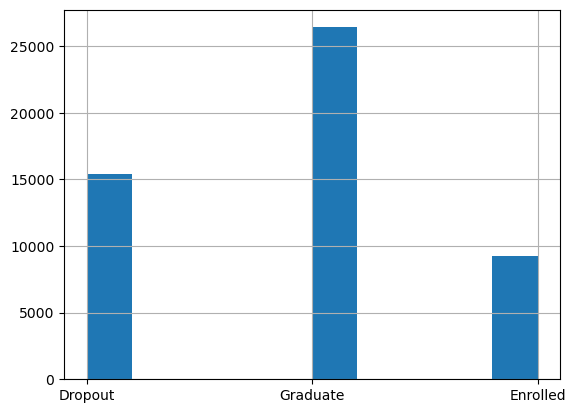

In [43]:
df_sub['Target'].hist()

| Implications                    | Actionable Insights                                        |
|---------------------------------|------------------------------------------------------------|
| **지원 대상 선정:**              | 학업 성적 개선과 어린 학생들에 대한 지원을 집중적으로 시행함으로써 졸업률을 향상시킬 수 있다.   |
|                                 | - 어린 학생들을 특히 대상으로 한 학업 성적 개선 프로그램을 개발한다.                      |
| **종합적인 지원:**              | 학업 성적과 함께 거시경제 요소를 고려하는 것은 학생들의 경험과 도전 과제를 이해하는 데 중요함. |
|                                 | - 지원 프로그램 설계 시 넓은 경제적 맥락을 고려한다.                                      |
| **포용적인 전략:**              | 장학금 수혜자들의 특별한 필요와 성별 역학을 이해하고 다양한 학생 인구를 지원하는 데 기여할 수 있다. |
|                                 | - 장학금 수혜자들을 위한 맞춤형 지원을 제공하고 교육에서의 포용성과 공정성을 촉진.        |
| **가족 참여:**                 | 학생들의 학업 여정에 가족을 참여시키는 것은 지원 네트워크를 강화하고 학생의 성공에 기여할 수 있다. |
|                                 | - 학생의 학업 노력을 가족이 지원하는 데 관여하도록 유도하며, 그들이 학생의 성공에 미치는 영향을 인식 |
| **인구 통계학적 고려 사항:**   | 결혼 상태와 나이와 같은 인구 통계학적 요소의 영향을 이해하여 포괄적인 지원 프로그램을 설계. |
|                                 | - 결혼 상태와 나이 등 인구 통계학적 요소를 기반으로 한 학생의 다양한 필요에 맞춘 지원 프로그램을 설계. |


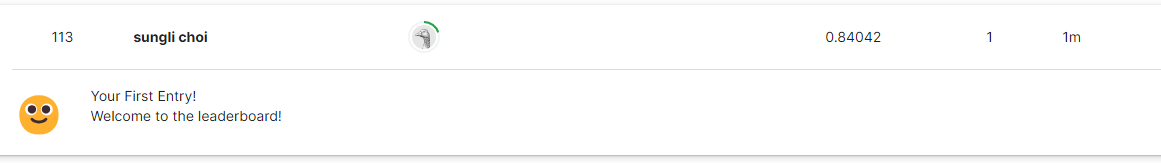
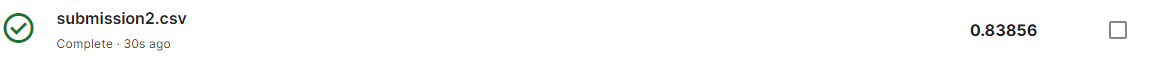
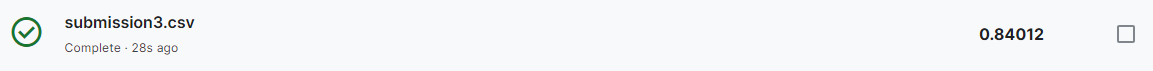